In [2]:
# =========================
# SECTION 1: LOAD + TARGET
# =========================

import numpy as np
import pandas as pd

pd.options.display.max_columns = None

# Load data
df_raw = pd.read_csv(r'C:\Users\Harsh Prakash\Desktop\Lending Club Credit Risk Project\loan.csv', low_memory=False)

df1 = df_raw.copy()

print("Shape:", df1.shape)
print(df1['loan_status'].value_counts(normalize=True))

Shape: (2260668, 145)
loan_status
Fully Paid                                             0.460904
Current                                                0.406824
Charged Off                                            0.115742
Late (31-120 days)                                     0.009686
In Grace Period                                        0.003960
Late (16-30 days)                                      0.001653
Does not meet the credit policy. Status:Fully Paid     0.000879
Does not meet the credit policy. Status:Charged Off    0.000337
Default                                                0.000014
Name: proportion, dtype: float64


In [3]:

print("\nLoan status:")
print(df1['loan_status'].value_counts(normalize=True))

#top missing variables more than 90% missing
print("\nTop missing:")
missing = df1.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0.9])



Loan status:
loan_status
Fully Paid                                             0.460904
Current                                                0.406824
Charged Off                                            0.115742
Late (31-120 days)                                     0.009686
In Grace Period                                        0.003960
Late (16-30 days)                                      0.001653
Does not meet the credit policy. Status:Fully Paid     0.000879
Does not meet the credit policy. Status:Charged Off    0.000337
Default                                                0.000014
Name: proportion, dtype: float64

Top missing:
id                                            1.000000
member_id                                     1.000000
url                                           1.000000
orig_projected_additional_accrued_interest    0.996273
hardship_amount                               0.995305
hardship_dpd                                  0.995305
hardship_loan_status 

In [4]:
df1.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,Chef,10+ years,RENT,55000.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,0.0,Apr-2001,1.0,NaN,45.0,9.0,1.0,4341,10.3,34.0,w,2386.02,2386.02,167.02,167.02,113.98,53.04,0.0,0.0,0.0,Feb-2019,84.92,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,0.0,16901.0,2.0,2.0,1.0,2.0,2.0,12560.0,69.0,2.0,7.0,2137.0,28.0,42000.0,1.0,11.0,2.0,9.0,1878.0,34360.0,5.9,0.0,0.0,140.0,212.0,1.0,1.0,0.0,1.0,NaN,2.0,NaN,0.0,2.0,5.0,3.0,3.0,16.0,7.0,18.0,5.0,9.0,0.0,0.0,0.0,3.0,100.0,0.0,1.0,0.0,60124.0,16901.0,36500.0,18124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,0.0,Jun-1987,0.0,71.0,75.0,13.0,1.0,12315,24.2,44.0,w,29387.75,29387.75,1507.11,1507.11,612.25,894.86,0.0,0.0,0.0,Feb-2019,777.23,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,1208.0,321915.0,4.0,4.0,2.0,3.0,3.0,87153.0,88.0,4.0,5.0,998.0,57.0,50800.0,2.0,15.0,2.0,10.0,24763.0,13761.0,8.3,0.0,0.0,163.0,378.0,4.0,3.0,3.0,4.0,NaN,4.0,NaN,0.0,2.0,4.0,4.0,9.0,27.0,8.0,14.0,4.0,13.0,0.0,0.0,0.0,6.0,95.0,0.0,1.0,0.0,372872.0,99468.0,15000.0,94072.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt cons

In [5]:
# -------------------------
# Define good / bad
# -------------------------
good_status = [
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid'
]

bad_status = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off'
]

In [6]:
# Filter relevant rows
df1 = df1[df1['loan_status'].isin(good_status + bad_status)].copy()

# Create target
df1['target'] = np.where(df1['loan_status'].isin(bad_status), 0, 1)


In [7]:
# Check distribution
# -------------------------
print("\nTarget distribution:")
print(df1['target'].value_counts(normalize=True))


Target distribution:
target
1    0.799105
0    0.200895
Name: proportion, dtype: float64


In [8]:
df1.shape

(1306387, 146)

In [9]:
##
# =========================
# CHECK TIME DISTRIBUTION (MANDATORY)
# =========================
df1['issue_d_dt'] = pd.to_datetime(df1['issue_d'], format='%b-%Y', errors='coerce')

print(df1.groupby(df1['issue_d_dt'].dt.year)['target'].agg(['count','mean']))

             count      mean
issue_d_dt                  
2007           603  0.737977
2008          2393  0.792729
2009          5281  0.863094
2010         12537  0.859855
2011         21721  0.848211
2012         53367  0.838027
2013        134793  0.844042
2014        221468  0.814619
2015        373412  0.798413
2016        274711  0.757276
2017        158910  0.771009
2018         47191  0.852705


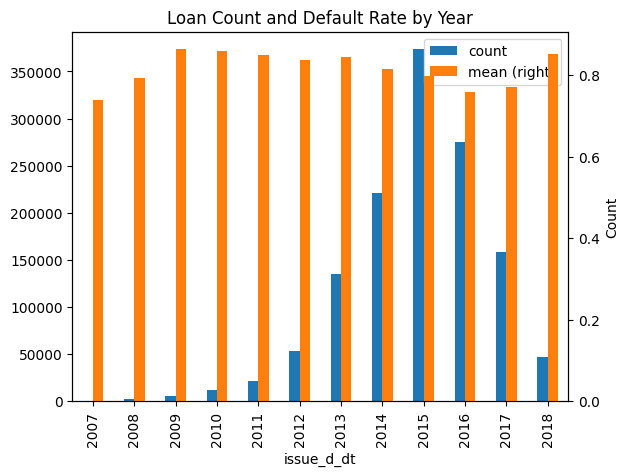

In [10]:
#DRAW graph of issue_d_dt year vs cumulative count

import matplotlib.pyplot as plt
df1.groupby(df1['issue_d_dt'].dt.year)['target'].agg(['count','mean']).plot(kind='bar', secondary_y='mean')
plt.title('Loan Count and Default Rate by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

In [11]:
leak_cols = [
    'out_prncp','out_prncp_inv',
    'total_pymnt','total_pymnt_inv',
    'total_rec_prncp','total_rec_int','total_rec_late_fee',
    'recoveries','collection_recovery_fee',
    'last_pymnt_d','last_pymnt_amnt',
    'next_pymnt_d'
]
drop_cols = [
    'id','member_id','url','desc','title','zip_code',
    'emp_title','pymnt_plan'
]
future_cols = [
    'last_credit_pull_d',
    'hardship_flag','hardship_type','hardship_reason','hardship_status',
    'debt_settlement_flag','debt_settlement_flag_date',
    'settlement_status','settlement_date','settlement_amount',
    'settlement_percentage','settlement_term'
]
df1.drop(columns=leak_cols + drop_cols + future_cols, inplace=True, errors='ignore')

print("New shape:", df1.shape)

New shape: (1306387, 115)


In [12]:
# =========================
# TIME SPLIT (DATA-DRIVEN)
# =========================

df1 = df1.sort_values('issue_d_dt')

train = df1[df1['issue_d_dt'] < '2014-01-01']
test  = df1[(df1['issue_d_dt'] >= '2014-01-01') & (df1['issue_d_dt'] < '2015-01-01')]
oot   = df1[df1['issue_d_dt'] >= '2015-01-01']

In [13]:
#Split
X_train = train.drop(columns=['target'])
y_train = train['target']

X_test  = test.drop(columns=['target'])
y_test  = test['target']

X_oot   = oot.drop(columns=['target'])
y_oot   = oot['target']


print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("OOT shape:", X_oot.shape)

print("\nTrain target dist:")
print(y_train.value_counts(normalize=True))

print("\nTest target dist:")
print(y_test.value_counts(normalize=True))

print("\nOOT target dist:")
print(y_oot.value_counts(normalize=True))

Train shape: (230695, 114)
Test shape: (221468, 114)
OOT shape: (854224, 114)

Train target dist:
target
1    0.843529
0    0.156471
Name: proportion, dtype: float64

Test target dist:
target
1    0.814619
0    0.185381
Name: proportion, dtype: float64

OOT target dist:
target
1    0.783085
0    0.216915
Name: proportion, dtype: float64


In [14]:
print("Bad rate ratio (OOT / Train):", 
      (1 - y_oot.mean()) / (1 - y_train.mean()))

Bad rate ratio (OOT / Train): 1.386298202229171


In [15]:

#display max columns
pd.options.display.max_columns = None


In [16]:
#display all columns and data types
print("\nData types:")
print(X_train.dtypes)


Data types:
loan_amnt                                              int64
funded_amnt                                            int64
funded_amnt_inv                                      float64
term                                                  object
int_rate                                             float64
                                                   ...      
orig_projected_additional_accrued_interest           float64
hardship_payoff_balance_amount                       float64
hardship_last_payment_amount                         float64
disbursement_method                                   object
issue_d_dt                                    datetime64[ns]
Length: 114, dtype: object


In [17]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type', 'verification_status_joint', 'sec_app_earliest_cr_line', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_loan_status', 'disbursement_method']
Numerical: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'annual_inc_joint', 'dti_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'tot

In [18]:
core_features = [
    # Loan structure
    'loan_amnt', 'term_int', 'int_rate', 'installment', 'purpose',

    # Borrower capacity
    'annual_inc', 'dti', 'emp_length_int', 'home_ownership', 'verification_status',

    # Credit history
    'mths_since_earliest_cr_line', 'total_acc', 'open_acc', 'avg_cur_bal', 'tot_cur_bal',

    # Delinquency / risk signals
    'delinq_2yrs', 'inq_last_6mths', 'num_tl_90g_dpd_24m',
    'num_accts_ever_120_pd', 'acc_now_delinq',
    'pub_rec', 'pub_rec_bankruptcies', 'tax_liens',

    # Utilization
    'revol_util', 'revol_bal', 'bc_util',
    'total_rev_hi_lim', 'total_bc_limit', 'all_util',

    # Recent activity
    'inq_last_12m', 'acc_open_past_24mths',
    'num_tl_op_past_12m', 'mths_since_recent_inq',

    # Segmentation
    'addr_state'
]



In [19]:
drop_features = [
    'all_util','bc_util','total_bc_limit',
    'avg_cur_bal','tot_cur_bal','revol_bal',
    'num_tl_90g_dpd_24m','num_accts_ever_120_pd',
    'inq_last_12m','acc_open_past_24mths',
    'num_tl_op_past_12m','mths_since_recent_inq'
]

#drop drop_features
X_train.drop(columns=drop_features, inplace=True, errors='ignore')
X_test.drop(columns=drop_features, inplace=True, errors='ignore')
X_oot.drop(columns=drop_features, inplace=True, errors='ignore')

In [20]:
print(*X_train.select_dtypes(include='object').columns, sep='\n')

term
grade
sub_grade
emp_length
home_ownership
verification_status
issue_d
loan_status
purpose
addr_state
earliest_cr_line
initial_list_status
application_type
verification_status_joint
sec_app_earliest_cr_line
hardship_start_date
hardship_end_date
payment_plan_start_date
hardship_loan_status
disbursement_method


In [21]:
print(*X_train.select_dtypes(include=['int64','float64']).columns, sep='\n')

loan_amnt
funded_amnt
funded_amnt_inv
int_rate
installment
annual_inc
dti
delinq_2yrs
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_util
total_acc
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
annual_inc_joint
dti_joint
acc_now_delinq
tot_coll_amt
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
total_rev_hi_lim
inq_fi
total_cu_tl
bc_open_to_buy
chargeoff_within_12_mths
delinq_amnt
mo_sin_old_il_acct
mo_sin_old_rev_tl_op
mo_sin_rcnt_rev_tl_op
mo_sin_rcnt_tl
mort_acc
mths_since_recent_bc
mths_since_recent_bc_dlq
mths_since_recent_revol_delinq
num_actv_bc_tl
num_actv_rev_tl
num_bc_sats
num_bc_tl
num_il_tl
num_op_rev_tl
num_rev_accts
num_rev_tl_bal_gt_0
num_sats
num_tl_120dpd_2m
num_tl_30dpd
pct_tl_nvr_dlq
percent_bc_gt_75
pub_rec_bankruptcies
tax_liens
tot_hi_cred_lim
total_bal_ex_mort
total_il_high_credit_limit
revol_bal_joint
sec_app_inq_last_6mths
sec_ap

In [22]:
time_vars = [
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_recent_bc',
    'mths_since_recent_inq',
    'mths_since_recent_revol_delinq'
]


In [23]:
drop_num = [
    'annual_inc_joint','dti_joint',
    'revol_bal_joint','sec_app_inq_last_6mths',
    'sec_app_mort_acc','sec_app_open_acc',
    'sec_app_revol_util','sec_app_open_act_il',
    'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med'
]


In [24]:
X_train = X_train.drop(columns=drop_num, errors='ignore')
X_test  = X_test.drop(columns=drop_num, errors='ignore')
X_oot   = X_oot.drop(columns=drop_num, errors='ignore')

print("After numeric filtering:", X_train.shape)

After numeric filtering: (230695, 91)


In [25]:
drop_cat_sparse = [
    'verification_status_joint',
    'sec_app_earliest_cr_line',
    'sec_app_mths_since_last_major_derog'
]

X_train.drop(columns=drop_cat_sparse, inplace=True, errors='ignore')
X_test.drop(columns=drop_cat_sparse, inplace=True, errors='ignore')
X_oot.drop(columns=drop_cat_sparse, inplace=True, errors='ignore')

print("After categorical sparse drop:", X_train.shape)

After categorical sparse drop: (230695, 88)


In [26]:
# FEATURE ENGINEERING

# TERM
for d in (X_train, X_test, X_oot):
    d['term_int'] = d['term'].str.replace(' months','').astype(float)

# EMP LENGTH
def clean_emp(df):
    df['emp_length_clean'] = df['emp_length']
    df['emp_length_clean'] = df['emp_length_clean'].str.replace('+ years','',regex=False)
    df['emp_length_clean'] = df['emp_length_clean'].str.replace('< 1 year','0',regex=False)
    df['emp_length_clean'] = df['emp_length_clean'].str.replace(' years','',regex=False)
    df['emp_length_clean'] = df['emp_length_clean'].str.replace(' year','',regex=False)
    df['emp_length_int'] = pd.to_numeric(df['emp_length_clean'], errors='coerce')

clean_emp(X_train)
clean_emp(X_test)
clean_emp(X_oot)

In [27]:
# CREATE earliest_cr_line_dt from earliest_cr_line

for d in (X_train, X_test, X_oot):
    d['earliest_cr_line_dt'] = pd.to_datetime(
        d['earliest_cr_line'],
        format='%b-%Y',
        errors='coerce'
    )

In [28]:
##
ref_date = X_train['issue_d_dt'].max()

for d in (X_train, X_test, X_oot):
    d.drop(columns=['mths_since_issue_d'], inplace=True, errors='ignore')
    d['mths_since_earliest_cr_line'] = ((ref_date - d['earliest_cr_line_dt']) / np.timedelta64(1,'D') / 30).round()
    d.loc[d['mths_since_earliest_cr_line'] < 0, 'mths_since_earliest_cr_line'] = 0

In [29]:
#show mths_since_earliest_cr_line
print(X_train['mths_since_earliest_cr_line'].describe())

count    230666.000000
mean        198.826754
std          85.233642
min          38.000000
25%         142.000000
50%         183.000000
75%         240.000000
max         827.000000
Name: mths_since_earliest_cr_line, dtype: float64


In [30]:
#drop original date columns and intermediate date columns
X_train.drop(columns=['issue_d_dt','earliest_cr_line_dt'], inplace=True, errors='ignore')
X_test.drop(columns=['issue_d_dt','earliest_cr_line_dt'], inplace=True, errors='ignore')
X_oot.drop(columns=['issue_d_dt','earliest_cr_line_dt'], inplace=True, errors='ignore')

In [31]:
##
# =========================
# CATEGORICAL MISSING ONLY
# =========================

cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

for col in cat_cols:
    X_train[col] = X_train[col].fillna('MISSING')
    X_test[col]  = X_test[col].fillna('MISSING')
    X_oot[col]   = X_oot[col].fillna('MISSING')

In [32]:
missing = X_train.isnull().mean()
high_missing_cols = missing[missing > 0.9].index.tolist()

for d in (X_train, X_test, X_oot):
    d.drop(columns=high_missing_cols, inplace=True, errors='ignore')

X_train.shape
X_test.shape
X_oot.shape

(854224, 71)

In [33]:
missing_cols = X_train.columns[X_train.isnull().sum() > 0]

print("Columns with missing:")
print(missing_cols)
print("\nCounts:")
print(X_train[missing_cols].isnull().sum())

Columns with missing:
Index(['annual_inc', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq',
       'open_acc', 'pub_rec', 'revol_util', 'total_acc',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'acc_now_delinq', 'tot_coll_amt', 'total_rev_hi_lim', 'bc_open_to_buy',
       'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_revol_delinq', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_30dpd', 'pct_tl_nvr_dlq', 'percent_bc_gt_75',
       'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim',
       'total_bal_ex_mort', 'total_il_high_credit_limit', 'emp_length_int',
       'mths_since_earliest_cr_line'],
      dtype='obj

In [34]:
# =========================
# MISSING VALUE TREATMENT
# =========================

# 1. TIME VARIABLES → 999
time_vars = [
    'mths_since_last_delinq',
    'mths_since_last_major_derog',
    'mths_since_recent_bc_dlq',
    'mths_since_recent_revol_delinq'
]

# 2. THIN FILE / STRUCTURAL → -1
structural_vars = [
    'tot_coll_amt','total_rev_hi_lim',
    'mo_sin_old_il_acct','mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op','mo_sin_rcnt_tl',
    'num_actv_bc_tl','num_actv_rev_tl',
    'num_bc_tl','num_il_tl','num_op_rev_tl',
    'num_rev_accts','num_rev_tl_bal_gt_0',
    'num_tl_30dpd','tot_hi_cred_lim',
    'total_il_high_credit_limit'
]

# 3. UTILIZATION EDGE → -1
util_vars = [
    'bc_open_to_buy','percent_bc_gt_75'
]

# APPLY
for col in time_vars:
    if col in X_train.columns:
        for d in (X_train, X_test, X_oot):
            d[col] = d[col].fillna(999)

for col in structural_vars + util_vars:
    if col in X_train.columns:
        for d in (X_train, X_test, X_oot):
            d[col] = d[col].fillna(-1)

# 4. NORMAL NUMERIC → MEDIAN
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

exclude = set(time_vars + structural_vars + util_vars)

for col in num_cols:
    if col not in exclude:
        median = X_train[col].median()
        for d in (X_train, X_test, X_oot):
            d[col] = d[col].fillna(median)

# 5. EMP LENGTH
for d in (X_train, X_test, X_oot):
    d['emp_length_int'].fillna(0, inplace=True)

C:\Users\Harsh Prakash\AppData\Local\Temp\ipykernel_960\1149315436.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d['emp_length_int'].fillna(0, inplace=True)


In [35]:
drop_cols = [
    'hardship_amount','hardship_start_date','hardship_end_date',
    'hardship_dpd','hardship_loan_status',
    'hardship_payoff_balance_amount',
    'hardship_last_payment_amount',
    'payment_plan_start_date',
    'deferral_term'
]
#DROP drop_cols
X_train.drop(columns=drop_cols, inplace=True, errors='ignore')
X_test.drop(columns=drop_cols, inplace=True, errors='ignore')
X_oot.drop(columns=drop_cols, inplace=True, errors='ignore')

In [36]:
##
X_train['emp_length_int'].fillna(0, inplace=True)
X_test['emp_length_int'].fillna(0, inplace=True)
X_oot['emp_length_int'].fillna(0, inplace=True)

# 0 represents unknown employment length (treated as separate risk segment)

C:\Users\Harsh Prakash\AppData\Local\Temp\ipykernel_960\840519387.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['emp_length_int'].fillna(0, inplace=True)
C:\Users\Harsh Prakash\AppData\Local\Temp\ipykernel_960\840519387.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [37]:
# =========================
# WINSORIZATION (CORRECT LOCATION)
# =========================

num_cols = X_train.select_dtypes(include=['int64','float64']).columns

winsor_cols = [
    'annual_inc', 'loan_amnt', 'installment',
    'revol_bal', 'open_acc', 'total_acc',
    'dti', 'int_rate'
]

for col in winsor_cols:
    if col in X_train.columns:
        lower = X_train[col].quantile(0.01)
        upper = X_train[col].quantile(0.99)

        for d in (X_train, X_test, X_oot):
            d[col] = d[col].clip(lower, upper)

In [38]:
print("Train missing:", X_train.isnull().sum().sum())
print("Test missing:", X_test.isnull().sum().sum())
print("OOT missing:", X_oot.isnull().sum().sum())

Train missing: 0
Test missing: 0
OOT missing: 0


In [39]:
#PRINT MISSING COLUMNS IN TRAIN
missing_cols = X_train.columns[X_train.isnull().sum() > 0]
print("Columns with missing values in train:")
print(missing_cols)



Columns with missing values in train:
Index([], dtype='object')


In [41]:
#shape of X_train and X_test
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_oot shape:", X_oot.shape)

X_train shape: (230695, 67)
X_test shape: (221468, 67)
X_oot shape: (854224, 67)


In [42]:
#print columns of X_train, X_test, X_oot
print("X_train columns:")
print(X_train.columns)
print("X_test columns:")
print(X_test.columns)
print("X_oot columns:")
print(X_oot.columns)

X_train columns:
Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec',
       'revol_util', 'total_acc', 'initial_list_status',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
       'total_rev_hi_lim', 'bc_open_to_buy', 'chargeoff_within_12_mths',
       'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
       'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
       'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_revol_delinq', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'n

In [ ]:
 #STAGE 2

#0. IMPORTS + PATH

import numpy as np
import pandas as pd
import os
import pickle

PROJECT_PATH = r"C:\Users\Harsh Prakash\Desktop\Lending Club Credit Risk Project"
ARTIFACTS_PATH = os.path.join(PROJECT_PATH, "artifacts")
os.makedirs(ARTIFACTS_PATH, exist_ok=True)

In [44]:
# REMOVE LEAKAGE

for d in (X_train, X_test, X_oot):
    d.drop(columns=['mths_since_issue_d'], inplace=True, errors='ignore')

In [45]:
#WOE IV TABLE FUNCTION

def woe_iv_table(df1, feature, target):

    temp = pd.concat([df1[feature], target], axis=1)
    temp.columns = [feature, 'target']
    
    table = temp.groupby(feature).agg(
        count=('target', 'count'),
        good=('target', 'sum')   # assuming 1 = good
    )

    table['bad'] = table['count'] - table['good']

    eps = 1e-6
    table['dist_good'] = (table['good'] + eps) / (table['good'].sum() + eps)
    table['dist_bad']  = (table['bad'] + eps) / (table['bad'].sum() + eps)

    table['WOE'] = np.log(table['dist_good'] / table['dist_bad'])
    table['IV'] = (table['dist_good'] - table['dist_bad']) * table['WOE']

    iv_total = table['IV'].sum()
    table = table.sort_index()

    return table.reset_index(), iv_total

In [46]:

def plot_woe(df1, var):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,8))
    plt.plot(df1[var], df1['WOE'], marker='o')
    plt.xticks(rotation=45)
    plt.title(f"WOE - {var}")
    plt.show()


def fine_classing(df1, var, bins=10):
    df1 = df1.copy()
    df1[var + '_factor'] = pd.qcut(df1[var], q=bins, duplicates='drop')
    return df1

In [47]:
# INTEREST RATE

def bin_int_rate(df1):
    df1 = df1.copy()

    df1['int_rate_bin'] = pd.cut(
        df1['int_rate'],
        bins=[0, 8, 11, 14, 18, 100],
        labels=['<8', '8-11', '11-14', '14-18', '>18']
    )

    df1['int_rate_bin'] = df1['int_rate_bin'].astype(str).replace('nan', 'MISSING')

    return df1

X_train = bin_int_rate(X_train)
X_test  = bin_int_rate(X_test)
X_oot   = bin_int_rate(X_oot)

woe_int, iv_int = woe_iv_table(X_train, 'int_rate_bin', y_train)
int_map = woe_int.set_index('int_rate_bin')['WOE'].to_dict()

for d in (X_train, X_test, X_oot):
    d['int_rate_woe'] = d['int_rate_bin'].map(int_map).fillna(0).astype(float)

#show woe table
print(woe_int)
print("IV:", iv_int)

  int_rate_bin  count   good    bad  dist_good  dist_bad       WOE        IV
0        11-14  57993  50644   7349   0.260249  0.203590  0.245530  0.013912
1        14-18  69071  56098  12973   0.288276  0.359393 -0.220496  0.015681
2         8-11  34169  31086   3083   0.159745  0.085409  0.626128  0.046544
3           <8  28303  26876   1427   0.138110  0.039532  1.250933  0.123314
4          >18  41159  29894  11265   0.153619  0.312076 -0.708769  0.112309
IV: 0.3117597969077468


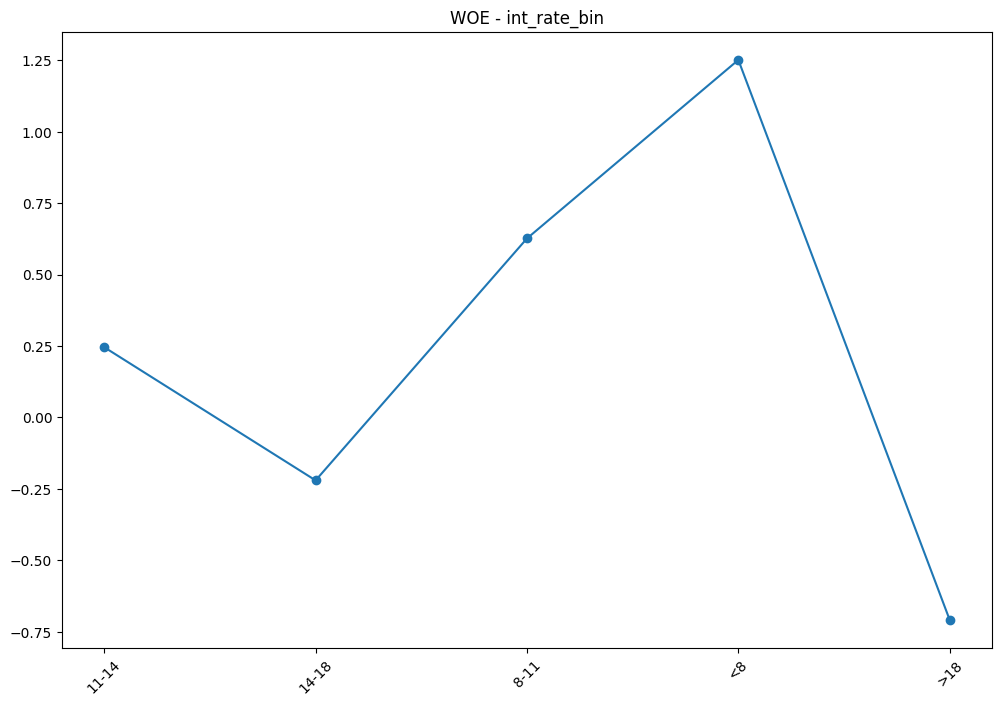

In [48]:
#plot woe for int_rate_bin
plot_woe(woe_int, 'int_rate_bin')

In [49]:
#DTI

def bin_dti(df1):
    df1 = df1.copy()
    df1['dti_bin'] = pd.cut(df1['dti'],
        bins=[-np.inf,10,20,30,np.inf],
        labels=['<10','10-20','20-30','>30'])
    df1['dti_bin'] = df1['dti_bin'].astype(str).replace('nan','MISSING')
    return df1

X_train = bin_dti(X_train)
X_test  = bin_dti(X_test)
X_oot   = bin_dti(X_oot)

woe_dti, iv_dti = woe_iv_table(X_train, 'dti_bin', y_train)
order = ['<10','10-20','20-30','>30']

woe_dti = (
    woe_dti
    .set_index('dti_bin')
    .reindex(order)
    .reset_index()
)
dti_map = woe_dti.set_index('dti_bin')['WOE'].to_dict()

for d in (X_train, X_test, X_oot):
    d['dti_woe'] = (
        d['dti_bin']
        .map(dti_map)
        .astype(float)
        .fillna(0)
    )

#show woe table
print(woe_dti)
print("IV:", iv_dti)

  dti_bin   count   good    bad  dist_good  dist_bad       WOE        IV
0     <10   51130  44889   6241   0.230676  0.172895  0.288326  0.016660
1   10-20  104898  89101  15797   0.457872  0.437626  0.045224  0.000916
2   20-30   65191  53079  12112   0.272762  0.335540 -0.207141  0.013004
3     >30    9476   7529   1947   0.038690  0.053938 -0.332254  0.005066
IV: 0.035645306024026074


In [ ]:
# NOTE:
# DTI bins reduced from 5 → 4
# (>30 combined) due to sparse observations and similar risk profile

In [50]:
X_train['dti_bin'].value_counts(dropna=False)

dti_bin
10-20    104898
20-30     65191
<10       51130
>30        9476
Name: count, dtype: int64

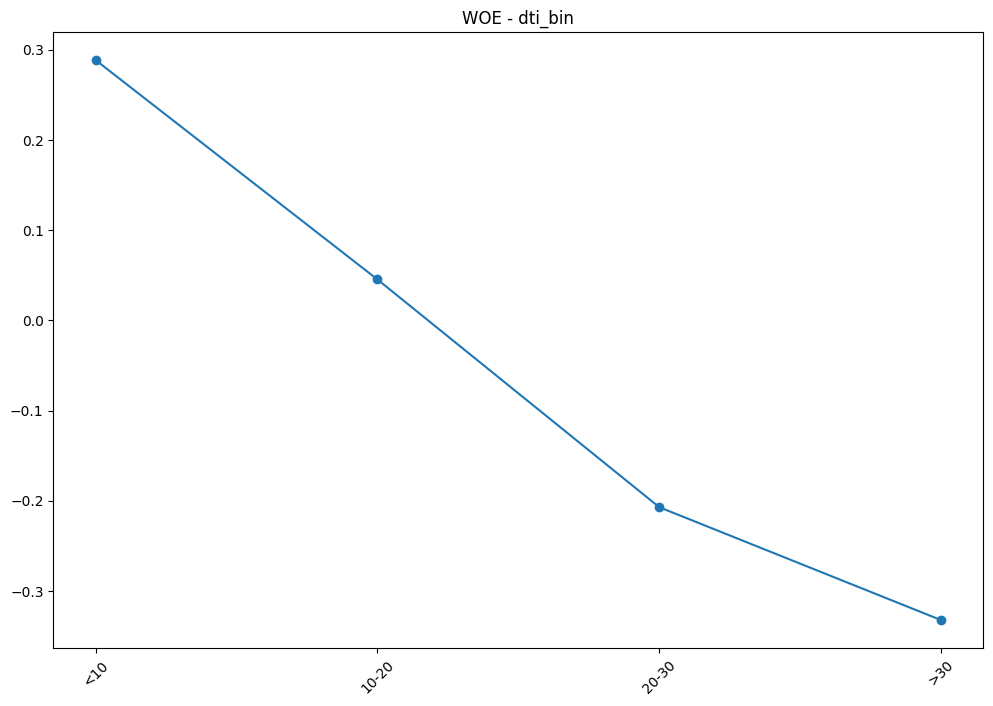

In [51]:
#plot woe for dti_bin
plot_woe(woe_dti, 'dti_bin')


In [52]:
# INCOME

for d in (X_train, X_test, X_oot):
    d['annual_inc_log'] = np.log(d['annual_inc'] + 1)

def bin_income(df1):
    df1 = df1.copy()
    df1['income_bin'] = pd.cut(df1['annual_inc_log'],
        bins=[-np.inf,10.5, 11.5,12, np.inf],
        labels=['low','mid','high','very_high'])
    df1['income_bin'] = df1['income_bin'].astype(str).replace('nan','MISSING')
    return df1

X_train = bin_income(X_train)
X_test  = bin_income(X_test)
X_oot   = bin_income(X_oot)

woe_inc, iv_inc = woe_iv_table(X_train, 'income_bin', y_train)
order = ['low','mid','high','very_high']

woe_inc = (
    woe_inc
    .set_index('income_bin')
    .reindex(order)   # safer than .loc
    .reset_index()
)
inc_map = woe_inc.set_index('income_bin')['WOE'].to_dict()

for d in (X_train, X_test, X_oot):
    d['income_woe'] = (
        d['income_bin']
        .map(inc_map)
        .astype(float)
        .fillna(0)
    )
#show woe table
print(woe_inc)
print("IV:", iv_inc)

  income_bin   count    good    bad  dist_good  dist_bad       WOE        IV
0        low   32978   26712   6266   0.137268  0.173588 -0.234751  0.008526
1        mid  157109  132016  25093   0.678404  0.695155 -0.024392  0.000409
2       high   33145   29247   3898   0.150294  0.107987  0.330587  0.013986
3  very_high    7463    6623    840   0.034034  0.023271  0.380176  0.004092
IV: 0.027013255990368835


In [53]:
X_train['income_bin'].value_counts(dropna=False)

income_bin
mid          157109
high          33145
low           32978
very_high      7463
Name: count, dtype: int64

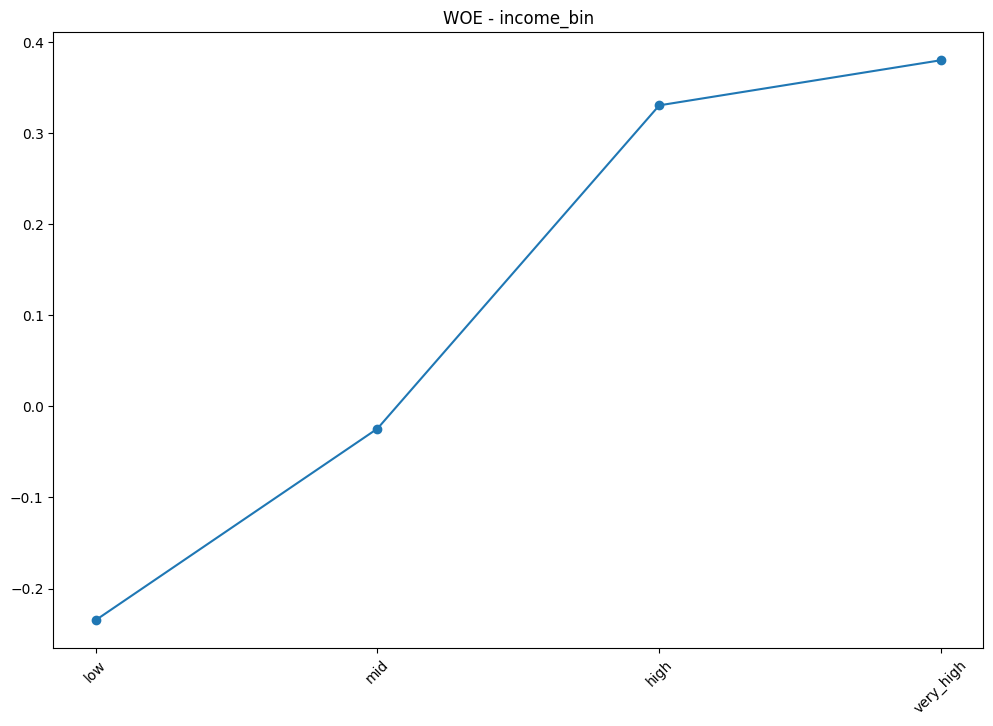

In [54]:
#plot woe for income_bin
plot_woe(woe_inc, 'income_bin')

In [55]:
# CAP
def cap_revol(df1):
    df1 = df1.copy()
    df1['revol_util'] = np.where(df1['revol_util'] > 100, 100, df1['revol_util'])
    return df1

X_train = cap_revol(X_train)
X_test  = cap_revol(X_test)
X_oot   = cap_revol(X_oot)


# BIN (ordered categorical)
def bin_revol(df1):
    df1 = df1.copy()
    
    df1['revol_util_bin'] = pd.cut(
        df1['revol_util'],
        bins=[-np.inf,20,40,60,80,100],
        labels=['<20','20-40','40-60','60-80','>80']
    )
    df1['revol_util_bin'] = df1['revol_util_bin'].astype(str).replace('nan','MISSING')
    
    return df1

X_train = bin_revol(X_train)
X_test  = bin_revol(X_test)
X_oot   = bin_revol(X_oot)


# WOE
woe_rev, iv_rev = woe_iv_table(X_train, 'revol_util_bin', y_train)

rev_map = woe_rev.set_index('revol_util_bin')['WOE'].to_dict()

for d in (X_train, X_test, X_oot):
    d['revol_util_woe'] = d['revol_util_bin'].map(rev_map).astype(float).fillna(0)

print(woe_rev)
print("IV:", iv_rev)

  revol_util_bin  count   good    bad  dist_good  dist_bad       WOE        IV
0          20-40  37735  32779   4956   0.168445  0.137297  0.204463  0.006369
1          40-60  60605  51426   9179   0.264268  0.254287  0.038499  0.000384
2          60-80  66624  55339  11285   0.284376  0.312630 -0.094723  0.002676
3            <20  20757  18595   2162   0.095556  0.059894  0.467133  0.016659
4            >80  44974  36459   8515   0.187355  0.235892 -0.230367  0.011181
IV: 0.03726919832232369


In [56]:
#count missing in revol_util_bin
print("Missing in revol_util_bin (train):", X_train['revol_util_bin'].isnull().sum())


Missing in revol_util_bin (train): 0


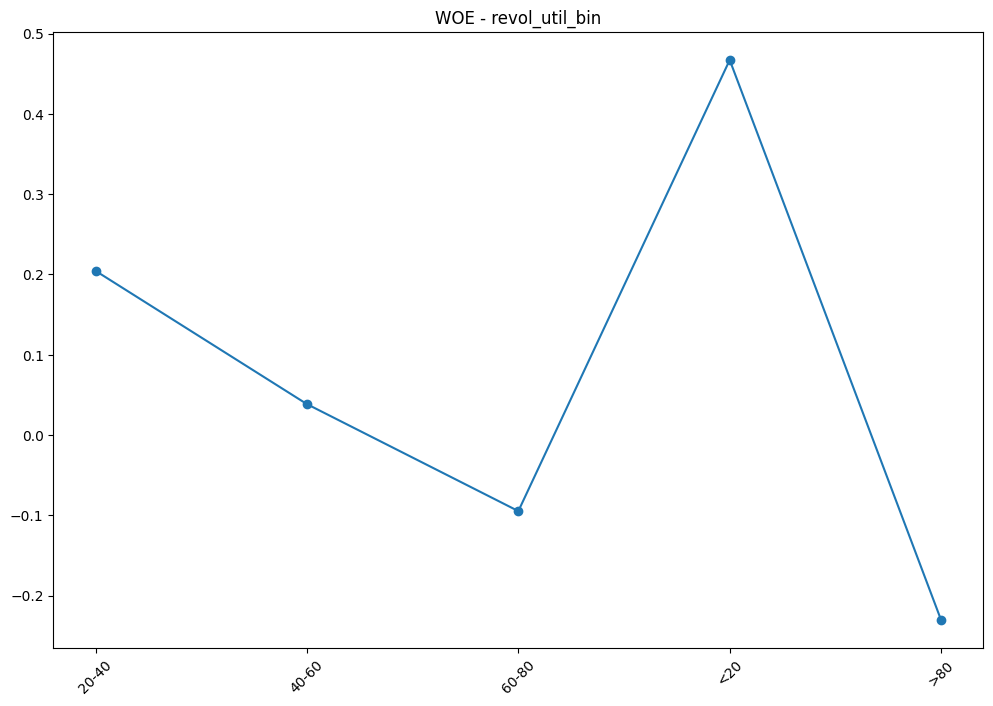

In [57]:
#plot woe for woe_rev
plot_woe(woe_rev, 'revol_util_bin')

In [58]:
# DELINQUENCY_2YRS

def bin_delinq(df1):
    df1 = df1.copy()
    df1['delinq_bin'] = 'other'
    df1.loc[df1['delinq_2yrs'].isna(),'delinq_bin']='MISSING'
    df1.loc[df1['delinq_2yrs']==0,'delinq_bin']='0'
    df1.loc[df1['delinq_2yrs']==1,'delinq_bin']='1'
    df1.loc[df1['delinq_2yrs']==2,'delinq_bin']='2'
    df1.loc[df1['delinq_2yrs'].isin([3,4,5]),'delinq_bin']='3-5'
    df1.loc[df1['delinq_2yrs']>5,'delinq_bin']='>5'
    return df1

X_train = bin_delinq(X_train)
X_test  = bin_delinq(X_test)
X_oot   = bin_delinq(X_oot)

woe_delinq, iv_delinq = woe_iv_table(X_train, 'delinq_bin', y_train)
delinq_map = woe_delinq.set_index('delinq_bin')['WOE'].to_dict()

for d in (X_train, X_test, X_oot):
    d['delinq_woe'] = d['delinq_bin'].map(delinq_map).astype(float).fillna(0)

print(woe_delinq)
print("IV:", iv_delinq)

  delinq_bin   count    good    bad  dist_good  dist_bad       WOE        IV
0          0  196235  165705  30530   0.851525  0.845777  0.006773  0.000039
1          1   24368   20499   3869   0.105340  0.107183 -0.017346  0.000032
2          2    6480    5390   1090   0.027698  0.030196 -0.086358  0.000216
3        3-5    3191    2660    531   0.013669  0.014710 -0.073407  0.000076
4         >5     421     344     77   0.001768  0.002133 -0.187890  0.000069
IV: 0.0004317346566646797


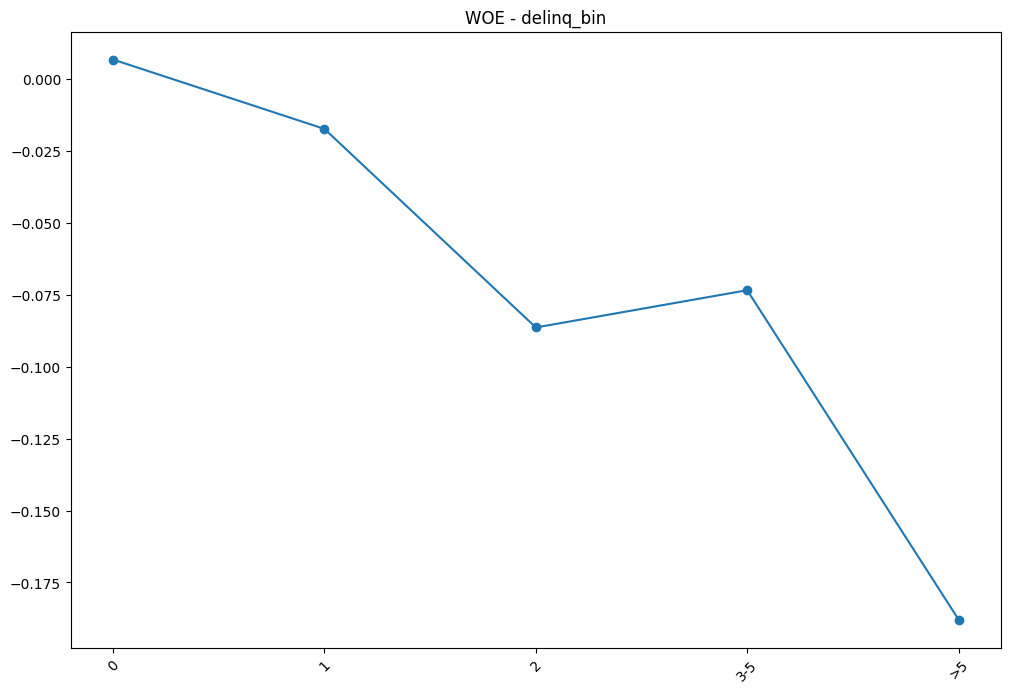

In [59]:
plot_woe(woe_delinq, 'delinq_bin')

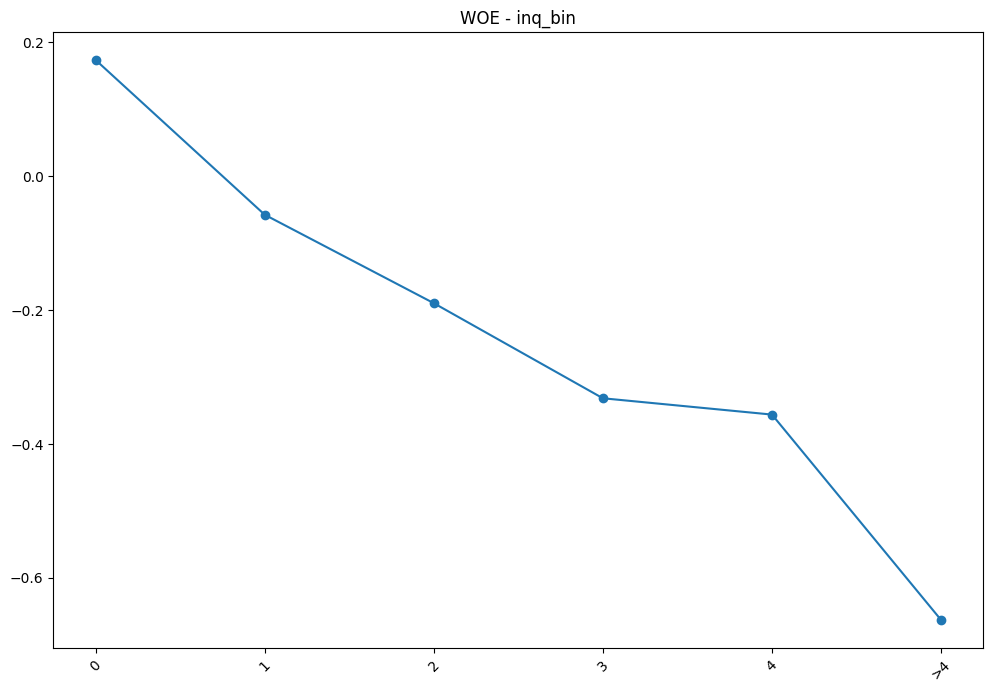

  inq_bin   count   good    bad  dist_good  dist_bad       WOE        IV
0       0  115530  99933  15597   0.513536  0.432086  0.172695  0.014066
1       1   64325  53755  10570   0.276236  0.292822 -0.058309  0.000967
2       2   30557  24957   5600   0.128249  0.155138 -0.190338  0.005118
3       3   14372  11419   2953   0.058680  0.081807 -0.332269  0.007685
4       4    3399   2687    712   0.013808  0.019725 -0.356623  0.002110
5      >4    2512   1847    665   0.009491  0.018423 -0.663195  0.005923
IV: 0.035868727278602394


In [60]:
# INQ LAST 6MTHS

def bin_inq(df1):
    df1 = df1.copy()
    df1['inq_bin'] = 'other'
    df1.loc[df1['inq_last_6mths'].isna(),'inq_bin']='MISSING'
    df1.loc[df1['inq_last_6mths']==0,'inq_bin']='0'
    df1.loc[df1['inq_last_6mths']==1,'inq_bin']='1'
    df1.loc[df1['inq_last_6mths']==2,'inq_bin']='2'
    df1.loc[df1['inq_last_6mths']==3,'inq_bin']='3'
    df1.loc[df1['inq_last_6mths']==4,'inq_bin']='4'
    df1.loc[df1['inq_last_6mths']>4,'inq_bin']='>4'
    return df1

X_train = bin_inq(X_train)
X_test  = bin_inq(X_test)
X_oot   = bin_inq(X_oot)

woe_inq, iv_inq = woe_iv_table(X_train, 'inq_bin', y_train)
inq_map = woe_inq.set_index('inq_bin')['WOE'].to_dict()

for d in (X_train, X_test, X_oot):
    d['inq_woe'] = d['inq_bin'].map(inq_map).astype(float).fillna(0)

plot_woe(woe_inq, 'inq_bin')
print(woe_inq)
print("IV:", iv_inq)

    home_bin   count   good    bad  dist_good  dist_bad       WOE        IV
0   MORTGAGE  115961  99332  16629   0.510447  0.460675  0.102593  0.005106
1  OWN_OTHER   18934  15907   3027   0.081743  0.083857 -0.025539  0.000054
2       RENT   95800  79359  16441   0.407810  0.455467 -0.110522  0.005267
IV: 0.010427461660846606


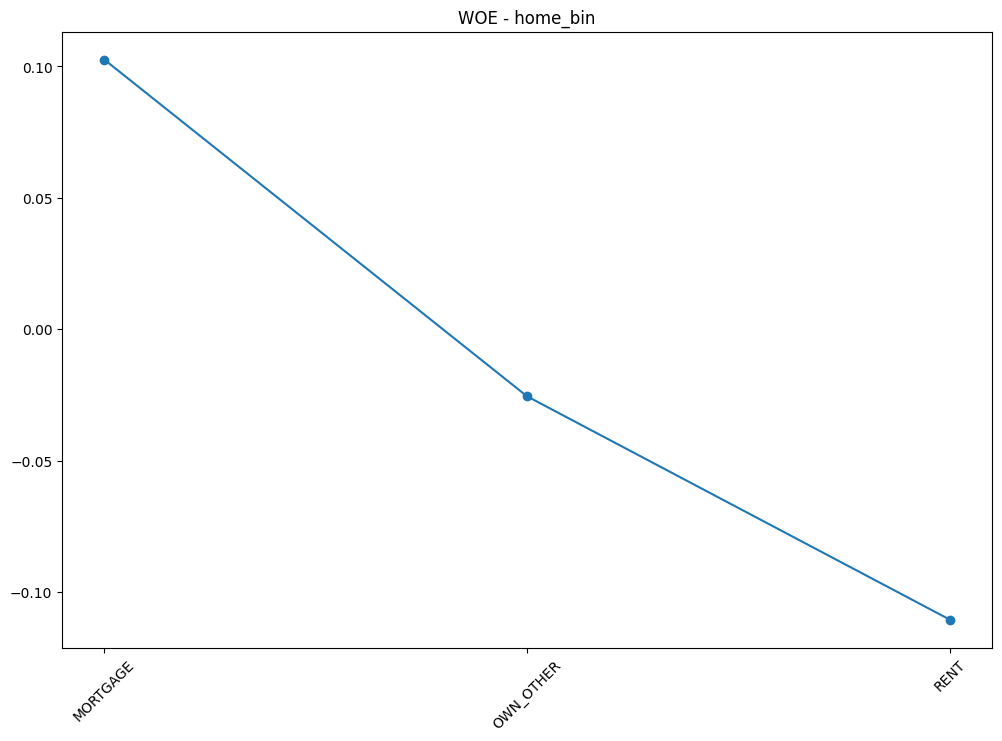

In [61]:
#CATEGORICAL: HOME OWNERSHIP

def preprocess_home(df1):
    df1 = df1.copy()
    df1['home_ownership'] = df1['home_ownership'].replace(
        ['ANY','NONE','OTHER'],'OTHER'
    )
    return df1

X_train = preprocess_home(X_train)
X_test  = preprocess_home(X_test)
X_oot   = preprocess_home(X_oot)

def bin_home(df1):
    df1 = df1.copy()
    df1['home_bin'] = df1['home_ownership'].replace({
        'OWN':'OWN_OTHER',
        'OTHER':'OWN_OTHER'
    })
    return df1

X_train = bin_home(X_train)
X_test  = bin_home(X_test)
X_oot   = bin_home(X_oot)

woe_home, iv_home = woe_iv_table(X_train, 'home_bin', y_train)
home_map = woe_home.set_index('home_bin')['WOE'].to_dict()

for d in (X_train, X_test, X_oot):
    d['home_woe'] = d['home_bin'].map(home_map).astype(float).fillna(0)

print(woe_home)
print("IV:", iv_home)
plot_woe(woe_home, 'home_bin')

  verification_status   count   good    bad  dist_good  dist_bad       WOE  \
0        Not Verified   77586  67711   9875   0.347953  0.273568  0.240516   
1     Source Verified   52261  43950   8311   0.225850  0.230241 -0.019253   
2            Verified  100848  82937  17911   0.426197  0.496191 -0.152060   

         IV  
0  0.017891  
1  0.000085  
2  0.010643  
IV: 0.02861859524534796


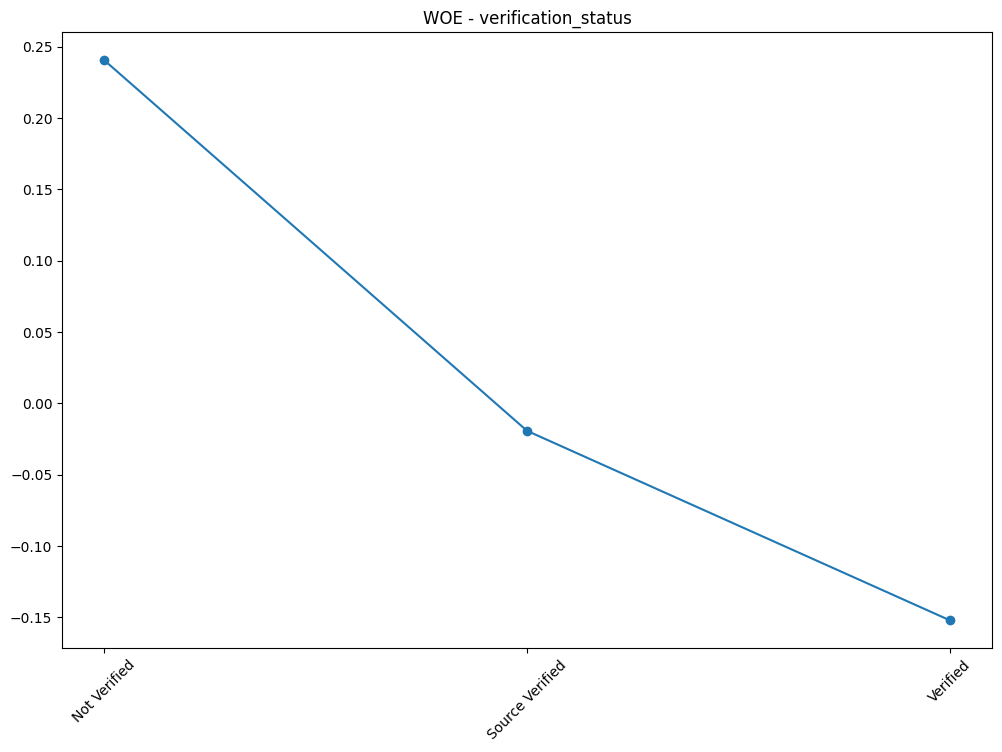

In [62]:
# CATEGORICAL: VERIFICATION STATUS

woe_ver, iv_ver = woe_iv_table(X_train, 'verification_status', y_train)
ver_map = woe_ver.set_index('verification_status')['WOE'].to_dict()

for d in (X_train, X_test, X_oot):
    d['verification_woe'] = d['verification_status'].map(ver_map).astype(float).fillna(0)
print(woe_ver)
print("IV:", iv_ver)
plot_woe(woe_ver, 'verification_status')

“Verification is often triggered for riskier borrowers,
so Verified customers may actually carry higher default risk.”

  purpose_bin   count    good    bad  dist_good  dist_bad       WOE        IV
0        high   10423    8208   2215   0.042179  0.061362 -0.374869  0.007191
1         low   71676   62470   9206   0.321021  0.255035  0.230105  0.015184
2      medium  148596  123920  24676   0.636800  0.683603 -0.070921  0.003319
IV: 0.025694105970240792


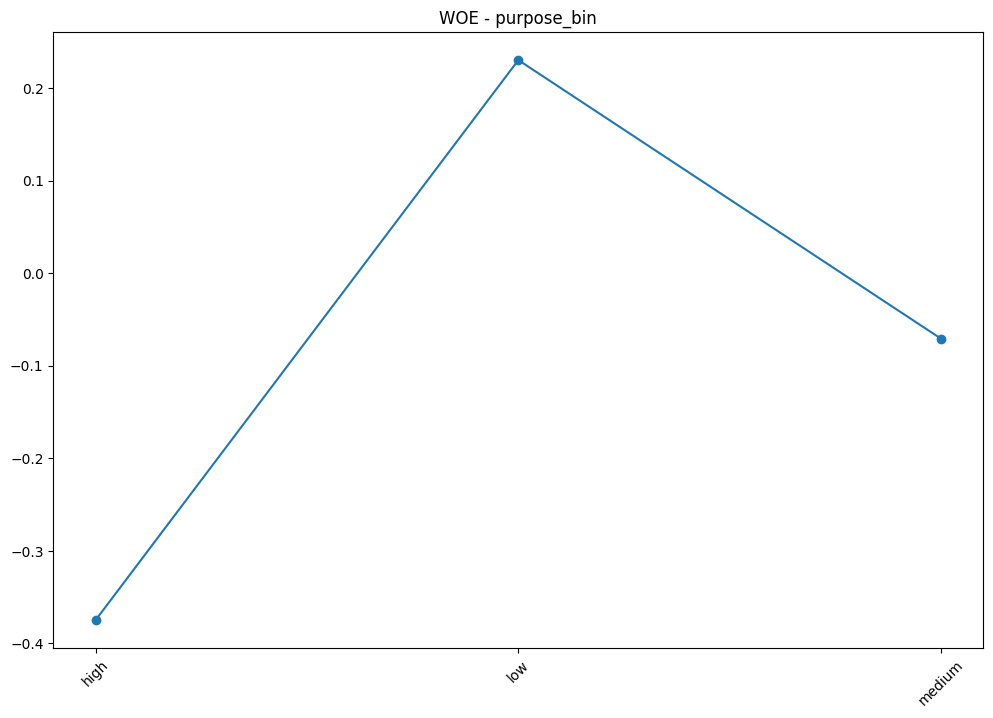

In [63]:
# CATEGORICAL: PURPOSE

def bin_purpose(df1):
    df1 = df1.copy()
    df1['purpose_bin'] = 'medium'
    df1.loc[df1['purpose'].isin(['credit_card','car','home_improvement','major_purchase']), 'purpose_bin'] = 'low'
    df1.loc[df1['purpose'].isin(['small_business','moving','medical','house','renewable_energy']), 'purpose_bin'] = 'high'
    return df1

X_train = bin_purpose(X_train)
X_test  = bin_purpose(X_test)
X_oot   = bin_purpose(X_oot)

woe_purpose, iv_purpose = woe_iv_table(X_train, 'purpose_bin', y_train)
purpose_map = woe_purpose.set_index('purpose_bin')['WOE'].to_dict()

for d in (X_train, X_test, X_oot):
    d['purpose_woe'] = d['purpose_bin'].map(purpose_map).astype(float).fillna(0)

print(woe_purpose)
print("IV:", iv_purpose)
plot_woe(woe_purpose, 'purpose_bin')

   state_bin  count   good    bad  dist_good  dist_bad       WOE        IV
0       high  69866  58540  11326   0.300825  0.313766 -0.042117  0.000545
1        low  32190  27887   4303   0.143306  0.119207  0.184122  0.004437
2     medium  82601  70253  12348   0.361016  0.342078  0.053883  0.001020
3  very_high  46038  37918   8120   0.194853  0.224949 -0.143630  0.004323
IV: 0.010325368950566655


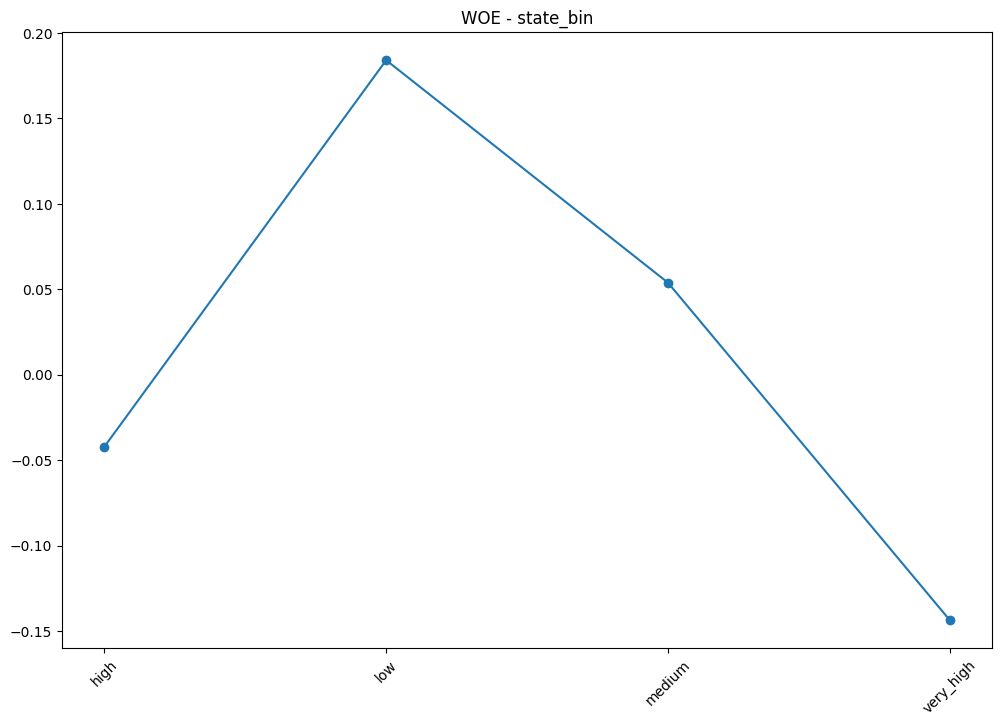

In [64]:
# CATEGORICAL: ADDR STATE

woe_state, _ = woe_iv_table(X_train, 'addr_state', y_train)

woe_state['group'] = pd.qcut(
    woe_state['WOE'],
    q=4,
    labels=['very_high','high','medium','low'],
    duplicates='drop'
)

state_map = {k: str(v) for k, v in 
             dict(zip(woe_state['addr_state'], woe_state['group'])).items()}

def bin_state(df1):
    df1 = df1.copy()
    df1['state_bin'] = df1['addr_state'].map(state_map).fillna('medium').astype(str)
    return df1

X_train = bin_state(X_train)
X_test  = bin_state(X_test)
X_oot   = bin_state(X_oot)

woe_state_final, iv_state = woe_iv_table(X_train, 'state_bin', y_train)
state_final_map = woe_state_final.set_index('state_bin')['WOE'].to_dict()

for d in (X_train, X_test, X_oot):
    d['state_woe'] = d['state_bin'].map(state_final_map).astype(float).fillna(0)

print(woe_state_final)
print("IV:", iv_state)
plot_woe(woe_state_final, 'state_bin')

“Purpose showed limited predictive power after grouping.
Despite clear segmentation, the IV remained low,
indicating weak discriminatory ability in this dataset.”

   term_int   count    good    bad  dist_good  dist_bad       WOE        IV
0      36.0  175426  153269  22157   0.787619  0.613818  0.249315  0.043331
1      60.0   55269   41329  13940   0.212381  0.386182 -0.597924  0.103919
IV: 0.14725036227898147


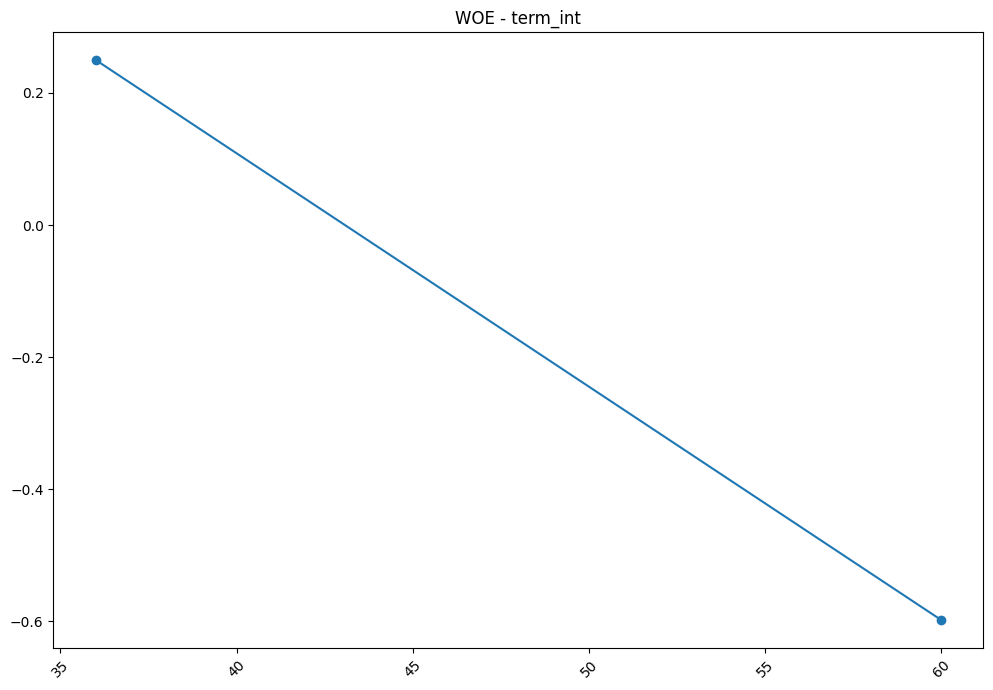

  grade  count   good    bad  dist_good  dist_bad       WOE        IV
0     A  38763  36533   2230   0.187736  0.061778  1.111488  0.140001
1     B  75011  66605   8406   0.342270  0.232873  0.385108  0.042130
2     C  58742  48372  10370   0.248574  0.287281 -0.144722  0.005602
3     D  33901  26257   7644   0.134929  0.211763 -0.450715  0.034630
4     E  15637  11194   4443   0.057524  0.123085 -0.760678  0.049871
5     F   7007   4596   2411   0.023618  0.066792 -1.039581  0.044883
6     G   1634   1041    593   0.005349  0.016428 -1.121983  0.012430
IV: 0.3295461180700533


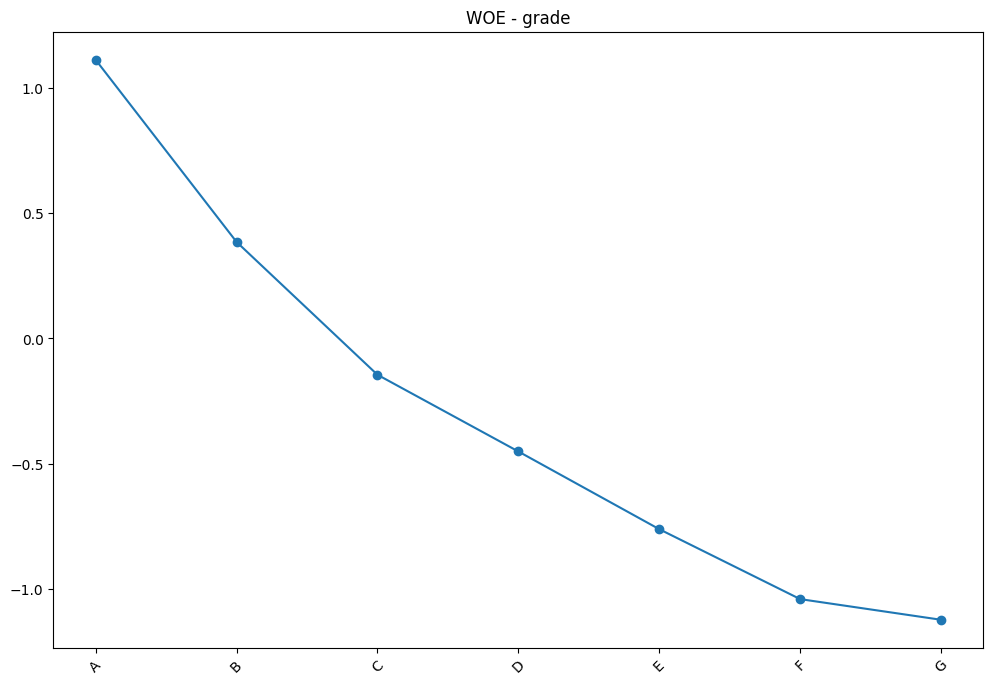

In [65]:
# CATEGORICAL: TERM AND GRADE (ORDERED → DIRECT WOE)

woe_term, iv_term = woe_iv_table(X_train, 'term_int', y_train)
woe_grade, iv_grade = woe_iv_table(X_train, 'grade', y_train)

term_map = woe_term.set_index('term_int')['WOE'].to_dict()
grade_map = woe_grade.set_index('grade')['WOE'].to_dict()

for d in (X_train, X_test, X_oot):
    d['term_woe'] = d['term_int'].map(term_map).astype(float).fillna(0)
    d['grade_woe'] = d['grade'].map(grade_map).astype(float).fillna(0)
print(woe_term)
print("IV:", iv_term)
plot_woe(woe_term, 'term_int')
print(woe_grade)
print("IV:", iv_grade)
plot_woe(woe_grade, 'grade')

In [66]:
#EMP LENGTH
#woe_emp, iv_emp = woe_iv_table(X_train, 'emp_length_int', y_train)
#emp_map = woe_emp.set_index('emp_length_int')['WOE'].to_dict()
#for d in (X_train, X_test, X_oot):
#    d['emp_length_woe'] = d['emp_length_int'].map(emp_map).fillna(0).astype(float)
    

If you include mths_since_issue_d in your training set, the model will see that loans with higher values (loans that stayed on the books longer) are less likely to have defaulted yet. It will "cheat" by using the loan's age to predict its survival, which is information you won't have when evaluating a new applicant tomorrow.

In [67]:
#CHECK MONOTONICITY

def check_monotonicity(woe_df, var_name):

    woe_vals = woe_df['WOE'].values

    increasing = all(x <= y for x, y in zip(woe_vals, woe_vals[1:]))
    decreasing = all(x >= y for x, y in zip(woe_vals, woe_vals[1:]))

    if increasing:
        trend = "Increasing"
    elif decreasing:
        trend = "Decreasing"
    else:
        trend = "Non-Monotonic"

    print(f"{var_name}: {trend}")
    return trend


# RUN CHECK
woe_tables = {
    'int_rate': woe_int,
    'dti': woe_dti,
    'income': woe_inc,
    'revol_util': woe_rev,
    'delinq': woe_delinq,
    'inq': woe_inq,
    'home': woe_home,
    'verification': woe_ver,
    'purpose': woe_purpose,
    'state': woe_state_final,
    'term': woe_term,
    'grade': woe_grade
}

monotonicity_report = {}

for var, table in woe_tables.items():
    monotonicity_report[var] = check_monotonicity(table, var)

int_rate: Non-Monotonic
dti: Decreasing
income: Increasing
revol_util: Non-Monotonic
delinq: Non-Monotonic
inq: Decreasing
home: Decreasing
verification: Decreasing
purpose: Non-Monotonic
state: Non-Monotonic
term: Decreasing
grade: Decreasing


In [68]:
#MINIMUM BIN SIZE CHECK

def check_min_bin_size(woe_df, var_name, threshold=0.05):

    temp = woe_df.copy()  # ✅ FIX

    total = temp['count'].sum()
    temp['pct'] = temp['count'] / total

    small_bins = temp[temp['pct'] < threshold]

    if small_bins.empty:
        print(f"{var_name}: OK")
    else:
        print(f"{var_name}: SMALL BINS FOUND")
        print(small_bins[[temp.columns[0], 'pct']])

    return small_bins

In [69]:
#IV FILTERING

iv_summary = pd.DataFrame({
    'variable': [
        'int_rate','dti','income','revol_util',
        'delinq','inq','home','verification',
        'purpose','state','term','grade'
    ],
    'iv': [
        iv_int, iv_dti, iv_inc, iv_rev,
        iv_delinq, iv_inq, iv_home, iv_ver,
        iv_purpose, iv_state, iv_term, iv_grade
    ]
})

# FILTER
iv_summary['keep'] = iv_summary['iv'].between(0.02, 0.5)

print(iv_summary.sort_values('iv', ascending=False))

selected_vars = iv_summary[iv_summary['keep']]['variable'].tolist()

print("\nSelected Variables:", selected_vars)


        variable        iv   keep
11         grade  0.329546   True
0       int_rate  0.311760   True
10          term  0.147250   True
3     revol_util  0.037269   True
5            inq  0.035869   True
1            dti  0.035645   True
7   verification  0.028619   True
2         income  0.027013   True
8        purpose  0.025694   True
6           home  0.010427  False
9          state  0.010325  False
4         delinq  0.000432  False

Selected Variables: ['int_rate', 'dti', 'income', 'revol_util', 'inq', 'verification', 'purpose', 'term', 'grade']


In [70]:
# MULTICOLLINEARITY CHECK

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use WOE variables only
woe_cols = [v + '_woe' for v in selected_vars]

X_vif = X_train[woe_cols].copy()

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\nVIF TABLE:")
print(vif_data.sort_values('VIF', ascending=False))


VIF TABLE:
            feature       VIF
8         grade_woe  7.242210
0      int_rate_woe  6.999897
7          term_woe  1.407308
3    revol_util_woe  1.331708
5  verification_woe  1.206905
1           dti_woe  1.129374
4           inq_woe  1.119480
2        income_woe  1.093061
6       purpose_woe  1.027846


# int_rate_woe and grade_woe are highly correlated
# (grade is derived from interest rate internally)
# We retain grade_woe as it captures broader risk segmentation
# and drop int_rate_woe to reduce multicollinearity
high_vif = ['int_rate_woe']

In [71]:
# DROP HIGH VIF
#high_vif = vif_data[vif_data['VIF'] > 5]['feature'].tolist()
high_vif = ['int_rate_woe']   # manually override
print("\nVariables removed due to high VIF:", high_vif)


Variables removed due to high VIF: ['int_rate_woe']


In [72]:
# Map base → woe names
var_to_woe = {v: v + '_woe' for v in selected_vars}

final_vars_stage2_5 = [var_to_woe[v] for v in selected_vars]

# Remove high VIF
final_vars_stage2_5 = [
    v for v in final_vars_stage2_5 if v not in high_vif
]

print("\nFINAL VARIABLES AFTER FILTERING:")
print(final_vars_stage2_5)


FINAL VARIABLES AFTER FILTERING:
['dti_woe', 'income_woe', 'revol_util_woe', 'inq_woe', 'verification_woe', 'purpose_woe', 'term_woe', 'grade_woe']


State is a high-cardinality categorical variable with noisy WOE estimates, so I applied quantile-based clustering on WOE values to group states into risk buckets, followed by a second WOE transformation to ensure stability and consistency in the final model.

Since I used WOE encoding, categorical variables were transformed into single continuous predictors, eliminating the need for explicit reference categories and avoiding the dummy variable trap

In [73]:
#create a copy of X_train and X_test for feature importance later
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()
X_oot_copy = X_oot.copy()

In [74]:
#check missing values in X_train and X_test
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [75]:
#show columns in X_train
print(X_train.columns.tolist())
print(X_test.columns.tolist())
print(X_oot.columns.tolist())

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'total_rev_hi_lim', 'bc_open_to_buy', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'pct_tl_nvr_dlq', 'percent_bc_gt_75

In [76]:
#drop loan_status column from X_train and X_test if exists
X_train.drop(columns=['loan_status'], inplace=True, errors='ignore')
X_test.drop(columns=['loan_status'], inplace=True, errors='ignore')
X_oot.drop(columns=['loan_status'], inplace=True, errors='ignore')

In [77]:
final_vars = final_vars_stage2_5

"Five C's of Credit" for feature selection:

Capacity (Ability to pay): income_woe, dti_woe.

Character (Willingness to pay): grade_woe, delinq_woe, inq_woe.

Capital/Conditions (Context of the loan): home_woe, purpose_woe, term_woe.

Collateral/Stability: state_woe, verification_woe.

In [78]:
missing_train = [v for v in final_vars if v not in X_train.columns]
missing_oot   = [v for v in final_vars if v not in X_oot.columns]

assert len(missing_train)==0, f"Missing train: {missing_train}"
assert len(missing_oot)==0, f"Missing oot: {missing_oot}"

In [79]:
X_train_model = X_train[final_vars_stage2_5].copy().astype(float)
X_test_model  = X_test[final_vars_stage2_5].copy().astype(float)
X_oot_model   = X_oot[final_vars_stage2_5].copy().astype(float)

X_train_model = X_train_model.fillna(0)
X_test_model  = X_test_model.fillna(0)
X_oot_model   = X_oot_model.fillna(0)

In [80]:
print("\nShapes:")
print(X_train_model.shape, len(y_train))
print(X_test_model.shape, len(y_test))
print(X_oot_model.shape, len(y_oot))

print("\nMissing:")
print(X_train_model.isnull().sum().sum(),
      X_test_model.isnull().sum().sum(),
      X_oot_model.isnull().sum().sum())

print("\nInfinite:")
print(np.isinf(X_train_model.values).sum(),
      np.isinf(X_test_model.values).sum(),
      np.isinf(X_oot_model.values).sum())


Shapes:
(230695, 8) 230695
(221468, 8) 221468
(854224, 8) 854224

Missing:
0 0 0

Infinite:
0 0 0


In [85]:
#print all columns in X_train_model
print("Columns in X_train_model:")
print(X_train_model.columns.tolist())


Columns in X_train_model:
['dti_woe', 'income_woe', 'revol_util_woe', 'inq_woe', 'verification_woe', 'purpose_woe', 'term_woe', 'grade_woe']


In [81]:
X_train_model.to_csv(os.path.join(ARTIFACTS_PATH,'X_train_model.csv'), index=False)
X_test_model.to_csv(os.path.join(ARTIFACTS_PATH,'X_test_model.csv'), index=False)
X_oot_model.to_csv(os.path.join(ARTIFACTS_PATH,'X_oot_model.csv'), index=False)

y_train.to_csv(os.path.join(ARTIFACTS_PATH,'y_train.csv'), index=False)
y_test.to_csv(os.path.join(ARTIFACTS_PATH,'y_test.csv'), index=False)
y_oot.to_csv(os.path.join(ARTIFACTS_PATH,'y_oot.csv'), index=False)

In [86]:
test[['loan_amnt']].to_csv(
    os.path.join(ARTIFACTS_PATH, "loan_amnt_test.csv"),
    index=False
)

In [82]:
woe_int.to_csv(os.path.join(ARTIFACTS_PATH,'woe_int.csv'), index=False)
woe_dti.to_csv(os.path.join(ARTIFACTS_PATH,'woe_dti.csv'), index=False)
woe_inc.to_csv(os.path.join(ARTIFACTS_PATH,'woe_income.csv'), index=False)
woe_rev.to_csv(os.path.join(ARTIFACTS_PATH,'woe_revol.csv'), index=False)
# repeat for all
woe_delinq.to_csv(os.path.join(ARTIFACTS_PATH,'woe_delinq.csv'), index=False)
woe_inq.to_csv(os.path.join(ARTIFACTS_PATH,'woe_inq.csv'), index=False)
woe_home.to_csv(os.path.join(ARTIFACTS_PATH,'woe_home.csv'), index=False)
woe_ver.to_csv(os.path.join(ARTIFACTS_PATH,'woe_verification.csv'), index=False)
woe_purpose.to_csv(os.path.join(ARTIFACTS_PATH,'woe_purpose.csv'), index=False)
woe_state_final.to_csv(os.path.join(ARTIFACTS_PATH,'woe_state.csv'), index=False)
woe_term.to_csv(os.path.join(ARTIFACTS_PATH,'woe_term.csv'), index=False)
woe_grade.to_csv(os.path.join(ARTIFACTS_PATH,'woe_grade.csv'), index=False)

In [83]:
print(os.listdir(ARTIFACTS_PATH))

['woe_delinq.csv', 'woe_dti.csv', 'woe_grade.csv', 'woe_home.csv', 'woe_income.csv', 'woe_inq.csv', 'woe_int.csv', 'woe_purpose.csv', 'woe_revol.csv', 'woe_state.csv', 'woe_term.csv', 'woe_verification.csv', 'X_oot_model.csv', 'X_test_model.csv', 'X_train_model.csv', 'y_oot.csv', 'y_test.csv', 'y_train.csv']


In [84]:
# SAVE MAPS
pickle.dump(int_map, open(os.path.join(ARTIFACTS_PATH,"map_int.pkl"),"wb"))
pickle.dump(dti_map, open(os.path.join(ARTIFACTS_PATH,"map_dti.pkl"),"wb"))
pickle.dump(inc_map, open(os.path.join(ARTIFACTS_PATH,"map_income.pkl"),"wb"))
pickle.dump(rev_map, open(os.path.join(ARTIFACTS_PATH,"map_revol.pkl"),"wb"))
pickle.dump(delinq_map, open(os.path.join(ARTIFACTS_PATH,"map_delinq.pkl"),"wb"))
pickle.dump(inq_map, open(os.path.join(ARTIFACTS_PATH,"map_inq.pkl"),"wb"))
pickle.dump(home_map, open(os.path.join(ARTIFACTS_PATH,"map_home.pkl"),"wb"))
pickle.dump(ver_map, open(os.path.join(ARTIFACTS_PATH,"map_ver.pkl"),"wb"))
pickle.dump(purpose_map, open(os.path.join(ARTIFACTS_PATH,"map_purpose.pkl"),"wb"))
pickle.dump(state_final_map, open(os.path.join(ARTIFACTS_PATH,"map_state.pkl"),"wb"))
pickle.dump(term_map, open(os.path.join(ARTIFACTS_PATH,"map_term.pkl"),"wb"))
pickle.dump(grade_map, open(os.path.join(ARTIFACTS_PATH,"map_grade.pkl"),"wb"))